In [123]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

### Parameter 

In [134]:
learning_rate = 0.01
training_steps = 100
display_step = 5

### Training Data

In [135]:
# Training_data

X = np.array([3.3,4.4,5.5,6.71,6.93,4.168,9.779,6.182,7.59,2.167,
              7.042,10.791,5.313,7.997,5.654,9.27,3.1])
Y = np.array([1.7,2.76,2.09,3.19,1.694,1.573,3.366,2.596,2.53,1.221,
              2.827,3.465,1.65,2.904,2.42,2.94,1.3])
Y.shape

(17,)

### Plotting Training Data

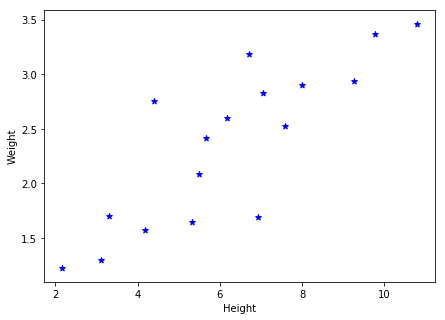

In [136]:
plt.figure(figsize=(7,5))
plt.scatter(X, Y, c='b', marker='*')
plt.xlabel("Height")
plt.ylabel("Weight")
plt.legend()

###  Weight and Bias Initilized Randomly

In [137]:
W = tf.Variable(np.random.randn(), name='weight')
b = tf.Variable(np.random.randn(), name='bias')

def linear_regression(x):
    return W * x + b


def mean_sqaure_error(y_pred, y_true):
    return tf.reduce_mean(tf.square(y_pred-y_true))

# Stochastic Gradient Descent Optimizer (Use one training example at time)

optimizer = tf.optimizers.SGD(learning_rate)

### Optimization Process

In [138]:
def run_optimization():
    with tf.GradientTape() as g:
        pred = linear_regression(X)
        loss = mean_sqaure_error(pred, Y)
        
    #   Compute Gradient
    gradients = g.gradient(loss, [W, b])
    
    #   update W and b following Gradient
    optimizer.apply_gradients(zip(gradients, [W, b]))

### Running Training for Given No. of Steps

In [156]:
error = []
for step in range(1, training_steps+1):
    run_optimization()
    
    if step % display_step == 0:
        pred = linear_regression(X)
        loss = mean_sqaure_error(pred, Y)
        error.append(loss)
        print("step: %i, loss: %f, W: %f, b: %f" % (step, loss, W.numpy(), b.numpy()))

step: 5, loss: 0.166119, W: 0.296027, b: 0.484084
step: 10, loss: 0.165825, W: 0.295490, b: 0.487886
step: 15, loss: 0.165538, W: 0.294961, b: 0.491642
step: 20, loss: 0.165257, W: 0.294437, b: 0.495352
step: 25, loss: 0.164983, W: 0.293920, b: 0.499017
step: 30, loss: 0.164716, W: 0.293409, b: 0.502639
step: 35, loss: 0.164456, W: 0.292905, b: 0.506216
step: 40, loss: 0.164201, W: 0.292406, b: 0.509751
step: 45, loss: 0.163953, W: 0.291914, b: 0.513242
step: 50, loss: 0.163710, W: 0.291427, b: 0.516692
step: 55, loss: 0.163474, W: 0.290947, b: 0.520099
step: 60, loss: 0.163243, W: 0.290472, b: 0.523466
step: 65, loss: 0.163017, W: 0.290003, b: 0.526792
step: 70, loss: 0.162797, W: 0.289539, b: 0.530078
step: 75, loss: 0.162583, W: 0.289081, b: 0.533324
step: 80, loss: 0.162373, W: 0.288629, b: 0.536530
step: 85, loss: 0.162169, W: 0.288182, b: 0.539698
step: 90, loss: 0.161969, W: 0.287741, b: 0.542828
step: 95, loss: 0.161774, W: 0.287304, b: 0.545920
step: 100, loss: 0.161584, W: 0.

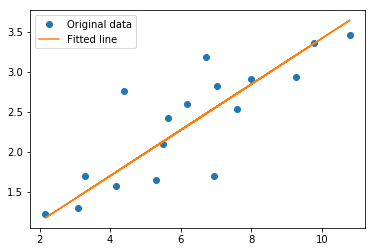

In [157]:
plt.plot(X, Y, 'o', label='Original data')
plt.plot(X, np.array(W * X + b), label='Fitted line')
plt.legend()
plt.show()